# Klasyfikacja drzewami decyzyjnymi i lasami losowymi: przycinanie, interpretowalność, k-NN


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml, load_iris

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,f1_score, accuracy_score, roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay

In [3]:
import graphviz

### Wczytanie danych

In [4]:
dataset_name = "adult"
ds = fetch_openml(name=dataset_name, version=2, as_frame=True)
df = ds.frame.copy()
df["income"] = (df['class'] == ">50K").astype(int)
df = df.drop(columns=["class"])
target_col = "income"
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


### Wstępna analiza EDA

In [5]:
df.shape

(48842, 15)

In [6]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [7]:
df['income'].value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

In [8]:
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df)*100).round(2),
    #unique
})

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numeric   ({len(num_cols)}): {num_cols}")
print(f"Categoric   ({len(cat_cols)}): {cat_cols}")

Numeric   (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categoric   (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [10]:
df[num_cols].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


C:\Users\kinga\AppData\Local\Temp\ipykernel_29460\2601550535.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vc = df.groupby(c)[target_col].mean().sort_values(ascending=False).head(10)
C:\Users\kinga\AppData\Local\Temp\ipykernel_29460\2601550535.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vc = df.groupby(c)[target_col].mean().sort_values(ascending=False).head(10)
C:\Users\kinga\AppData\Local\Temp\ipykernel_29460\2601550535.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

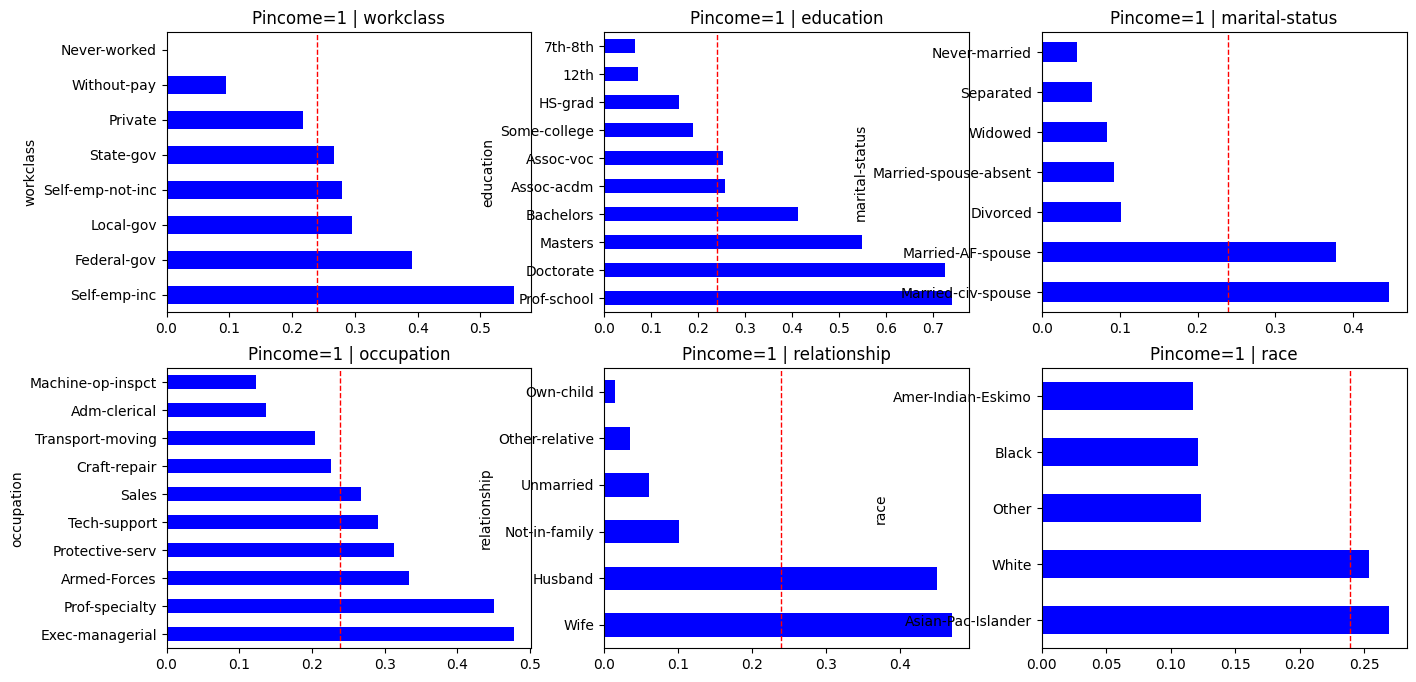

In [11]:
if cat_cols:
    fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16,8))
    axes = np.array(axes).ravel()
    for i, c in enumerate(cat_cols[:6]):
        vc = df.groupby(c)[target_col].mean().sort_values(ascending=False).head(10)
        vc.plot(kind='barh', ax=axes[i], color='blue', ls='--', lw=1)
        axes[i].axvline(df[target_col].mean(), color='red', ls='--', lw=1)
        axes[i].set_title(f"P{target_col}=1 | {c}")
        axes[i].set_xlabel('')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout; plt.show()

## Drzewa decyzyjne

### Pipeline

In [13]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preproc = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

feature_names = num_cols + cat_cols
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, {y_train.shape} | Test: {X_test.shape}, {y_test.shape}")
print(f"Rozkład klas w zbiorze treningowym:\n{y_train.value_counts(normalize=True)}")

Train: (24421, 14), (24421,) | Test: (24421, 14), (24421,)
Rozkład klas w zbiorze treningowym:
income
0    0.760698
1    0.239302
Name: proportion, dtype: float64


### Drzewo bazowe + walidacja krzyżowa

In [14]:
base_pipe = Pipeline([
    ('preproc', preproc),
    ('clf', DecisionTreeClassifier(random_state=42))
])

base_pipe.fit(X_train, y_train)
print(f"Pełne drzewo: głębokość: {base_pipe.named_steps['clf'].get_depth()}, liście: {base_pipe.named_steps['clf'].get_n_leaves()}")
print(f"Trening Accuracy: {base_pipe.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {base_pipe.score(X_test, y_test):.4f}")

Pełne drzewo: głębokość: 42, liście: 3573
Trening Accuracy: 0.9999
Test Accuracy: 0.8139


In [15]:
# cv over max depths
depths = list(range(1, 21))
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for d in depths:
    pipe = Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))
    ])
    s = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='balanced_accuracy', n_jobs=-1)
    cv_scores.append((s.mean(), s.std()))

cv_df = pd.DataFrame(cv_scores, columns=['mean', 'std'], index=depths)
best_depth = cv_df['mean'].idxmax()
print(f"Najlepsza głębokość: {best_depth}, z wynikiem (Accuracy +- std) {cv_df.loc[best_depth, 'mean']:.4f} ± {cv_df.loc[best_depth, 'std']:.4f}")

Najlepsza głębokość: 10, z wynikiem (Accuracy +- std) 0.7691 ± 0.0156


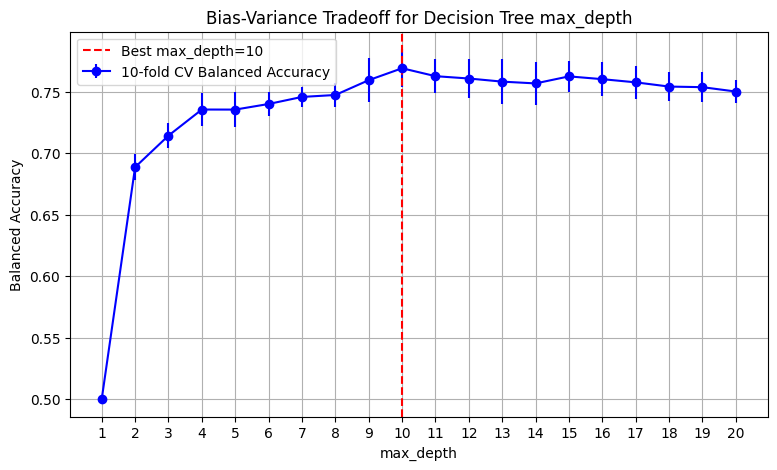

In [16]:
# wykres bias-variance
fig, ax = plt.subplots(figsize=(9,5))
ax.errorbar(cv_df.index, cv_df['mean'], yerr=cv_df['std'], fmt='-o', color='blue', label='10-fold CV Balanced Accuracy')
ax.axvline(best_depth, color='red', ls='--', label=f'Best max_depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Bias-Variance Tradeoff for Decision Tree max_depth')
plt.grid()
ax.legend()
ax.set_xticks(depths)
plt.show()

###  Cost-Complexity Pruning

In [35]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train_preproc, y_train)

path = full_tree.cost_complexity_pruning_path(X_train_preproc, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train_preproc, y_train)
    clfs.append(clf)

train_scores = [clf.score(X_train_preproc, y_train) for clf in clfs]
test_scores = [clf.score(X_test_preproc, y_test) for clf in clfs]
node_counts = [clf.tree_.node_count for clf in clfs]
depths = [clf.tree_.max_depth for clf in clfs]
leaf_counts = [clf.get_n_leaves() for clf in clfs]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax[0].plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax[0].set_xlabel("ccp_alpha (skala log)")
ax[0].set_ylabel("accuracy")
ax[0].set_title("Accuracy vs alpha")
ax[0].set_xscale('log')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(ccp_alphas, leaf_counts, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("ccp_alpha (skala log)")
ax[1].set_ylabel("liczba liści")
ax[1].set_title("Liczba liści vs alpha")
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'X_train_preproc' is not defined